OPENAI_API_KEY loaded: Yes
LangChain/OpenAI test: content='Hello! How can I assist you today?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 13, 'total_tokens': 22, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6c2953e649', 'id': 'chatcmpl-Dnk98JJ9YDRgMVwcTtvmLT6oSMizQ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e9cd7-7dfe-7822-af0c-646ef137edd1-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 13, 'output_tokens': 9, 'total_tokens': 22, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
LangGraph test: {'msg': 'LangGraph is working!'}


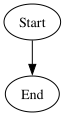

In [1]:
# ============================
# 1. Load environment variables
# ============================

import os
from dotenv import load_dotenv

load_dotenv()  # Automatically loads .env from project root

print("OPENAI_API_KEY loaded:", "Yes" if os.getenv("OPENAI_API_KEY") else "No")


# ============================
# 2. Import core AI libraries
# ============================

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END


# ============================
# 3. Quick sanity checks
# ============================

# Test OpenAI client
llm = ChatOpenAI(model="gpt-4o-mini")
response = llm.invoke("Hello from your local setup!")
print("LangChain/OpenAI test:", response)

# Test LangGraph
def node_fn(state):
    return {"msg": "LangGraph is working!"}

graph = StateGraph(dict)
graph.add_node("test", node_fn)
graph.set_entry_point("test")
graph.add_edge("test", END)

app = graph.compile()
print("LangGraph test:", app.invoke({}))


# ============================
# 4. Optional: Graphviz test
# ============================

from graphviz import Digraph

dot = Digraph()
dot.node("A", "Start")
dot.node("B", "End")
dot.edge("A", "B")

dot


In [2]:
import os
from typing import Sequence, Annotated, TypedDict
from operator import add as add_messages
from dotenv import load_dotenv
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    ToolMessage,
    BaseMessage
)

In [3]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

from langchain_chroma import Chroma
from langchain_core.tools import tool


/var/folders/rd/6k050wp925ng6d5b9bghly700000gn/T/ipykernel_89880/1445507808.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


In [4]:

base_llm = ChatOpenAI(model="gpt-4o", temperature=0)


In [5]:
embeddings = OpenAIEmbeddings(model = "text-embedding-3-small")

In [6]:
text_path = "hr_policy.txt"
if not os.path.exists(text_path):
    raise FileNotFoundError(f'Text file not found: {text_path}')
text_loader = TextLoader(text_path)
documents = text_loader.load()
# from pprint import pprint
# pprint(documents[0].page_content)

In [7]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap =20
)

chunks = text_splitter.split_documents(documents)
# print(chunks[0])
# print("====================================")
# print(chunks[1])

In [8]:
vector_store = Chroma.from_documents(chunks, embeddings)

retriever = vector_store.as_retriever(
    search_type = "similarity",
    search_kwargs={"k": 4} # Kis the amount of chunks to return
)

In [9]:
@tool
def policy_lookup(query: str) -> str:
    """Search the company polict handbook and return relevant sections"""
    docs = retriever.invoke(query)
    if not docs:
        return "No matching policy section found."
    out = []
    for i,d in enumerate(docs,1):
        source = d.metadata.get("source", text_path)
        out.append(f"[{source} - chunk {i}]\n{d.page_content.strip()}")
        return "\n\n.join(out)"

In [10]:
tools = [policy_lookup]
base_llm.bind_tools(tools)

_ChatModelBinding(bound=ChatOpenAI(output_version=None, profile={'name': 'GPT-4o', 'release_date': '2024-05-13', 'last_updated': '2024-08-06', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x13a509d00>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x13d1fa570>, root_client=<openai.OpenAI object at 0x13a59ac60>, root_async_client=<openai.AsyncOpenAI object at 0x13a509d60>, model_name='gpt-4o', temperature=0.0, model_kwargs={

In [11]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [12]:
def should_continue(state: AgentState) -> bool:
    """Check if the last message contains tool calls"""
    last = state["messages"][-1]
    return getattr(last, "tool_calls", None) not in (None, [])

In [13]:
system_prompt = """

"You are the company HR assistant."
"Answer employee questions uing only the official policy handbook."
"Call the policy_lookup tool whenever you need to search."
"Always cite the chunk text you used in square brackets at the end of the sentences."
"""


In [14]:
tools_dict = {our_tool.name: our_tool for our_tool in tools}

def _call_llm(state: AgentState) -> AgentState:
    msgs = list(state['messages'])
    if not msgs or not isinstance(msgs[0], SystemMessage):
        msgs.insert(0, SystemMessage(content=system_prompt))
        reply = llm.invoke(msgs)
    return {"messages": [reply]}

In [15]:
rom IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(agent.get_graph().draw_png()))


SyntaxError: invalid syntax (1663774745.py, line 1)